<a href="https://colab.research.google.com/github/shrutivaghasia15/eng-ai-agents/blob/main/assignments/assignment-1/assignment-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: detecting a grid anomaly from regression residuals

Winter Storm Uri caused widespread generation failures across Texas in February 2021. As temperatures
fell and demand rose, ERCOT began shedding load early on 15 February to prevent a wider grid collapse.
Millions of customers lost power, and the consequences were severe. Read the background article linked below
to understand the event before starting the assignment.
[2021 Texas power crisis](https://en.wikipedia.org/wiki/2021_Texas_power_crisis).


You will fit a model of normal grid behaviour and test whether its residuals distinguish the storm week
from an ordinary week. Use the ridge regression from the [linear regression](https://aegean.ai/aiml-common/lectures/regression/linear-regression) and
[SGD](https://aegean.ai/aiml-common/lectures/regression/linear-regression/sgd) pages, fitted by
stochastic gradient descent. This assignment uses a richer design matrix than those examples.

Build a detection rule from the residuals and evaluate it against the control week. Report the result even
if the two windows do not separate cleanly.

## Points

| Component | Points |
|---|---|
| Data retrieval and the load and temperature join | 10 |
| Design matrix construction | 15 |
| Ridge fitted by SGD, with lambda selected on held-out error | 20 |
| Model correctly frozen and applied to both evaluation windows | 15 |
| Signed residual analysis | 15 |
| Detection rule, threshold choice and evaluation against the control | 15 |
| Written discussion | 10 |

In [1]:
!pip install gridstatusio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 48.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


In [2]:
import os
from google.colab import userdata

os.environ["GRIDSTATUS_API_KEY"] = userdata.get("GRIDSTATUS_API_KEY")

In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from gridstatusio import GridStatusClient

load_dotenv()
client = GridStatusClient(os.environ["GRIDSTATUS_API_KEY"])

## Part 0: why time of day is not enough

The SGD example models load against time of day. That is not enough here: winter demand also depends
strongly on temperature.

An anomaly score is useful only if the baseline is reasonably accurate on ordinary days. Begin by measuring
that baseline error.


The design matrix includes nonlinear temperature terms, calendar indicators, and interactions between
temperature and hour of day.

### The three windows

The analysis uses three time windows.

| Window | Familiar name | What it is for |
|---|---|---|
| `train` | training set | fits the weights, the scalers and $\lambda$ |
| `control` | test set | data the model has never seen, on ordinary days |
| `event` | no equivalent | the week you are asking about |

Training error is an optimistic reference because the model was fitted on those observations. The control
window provides a better estimate of ordinary out-of-sample error. Compare the event residuals with that
control distribution.



In [4]:
ZONES = ["coast", "east", "far_west", "north", "north_central", "south_central", "southern", "west"]

def fetch_window(start, end):
    """Hourly ERCOT load joined to statewide mean temperature."""
    time.sleep(1.2)                                    # the API permits one request per second
    ld = client.get_dataset(dataset="ercot_load", start=start, end=end,
                            timezone="market", verbose=False)
    ld = pd.DataFrame({"t": pd.to_datetime(ld["interval_start_local"]), "load": ld["load"]})
    ld = ld.set_index("t").resample("1h").mean().dropna()

    time.sleep(1.2)
    tp = client.get_dataset(dataset="ercot_temperature_forecast_by_weather_zone",
                            start=start, end=end, timezone="market", verbose=False)
    tp["t"] = pd.to_datetime(tp["interval_start_local"])
    # each interval carries several forecast vintages; keep the most recently published
    tp = tp.sort_values("publish_time_utc").groupby("t").last()
    zc = [z for z in ZONES if z in tp.columns]
    tp["temp"] = tp[zc].mean(axis=1)
    tp = tp[["temp"]].resample("1h").mean().dropna()

    df = ld.join(tp, how="inner").dropna()
    df["hour"] = df.index.hour
    df["dow"] = df.index.dayofweek
    return df


train   = fetch_window("2020-12-01", "2021-02-08")   # ordinary winter, fits the baseline
control = fetch_window("2021-02-08", "2021-02-14")   # ordinary days, checks the detector stays quiet
event   = fetch_window("2021-02-14", "2021-02-20")   # Winter Storm Uri

for name, d in [("train", train), ("control", control), ("event", event)]:
    print(f"{name:8} {len(d):5} hours   load {d['load'].min():.0f} to {d['load'].max():.0f} MW"
          f"   temp {d['temp'].min():.0f} to {d['temp'].max():.0f} F")

train.head()          # one row per hour: load in MW, temperature in F, and the calendar columns

train     1656 hours   load 31011 to 57960 MW   temp 29 to 77 F
control    144 hours   load 34278 to 63635 MW   temp 26 to 68 F
event      144 hours   load 39802 to 69183 MW   temp 9 to 44 F


,load,temp,hour,dow
t,,,,
2020-12-01 00:00:00-06:00,43442.166667,33.96875,0,1
2020-12-01 01:00:00-06:00,43404.583333,32.80000,1,1
2020-12-01 02:00:00-06:00,43823.333333,31.75625,2,1
2020-12-01 03:00:00-06:00,44809.250000,32.18125,3,1
2020-12-01 04:00:00-06:00,46786.583333,31.28125,4,1


In [6]:
# Split the training window into learning and held-out validation data.
# The last two weeks are held out for validation.
cutoff = pd.Timestamp("2021-01-25", tz="US/Central")

df_train_learn = train[train.index < cutoff]
df_train_validate = train[train.index >= cutoff]

display(df_train_learn)
display(df_train_validate)

# Create design matrices for the learning and held-out validation data.
x_learn = design(df_train_learn)
x_validate = design(df_train_validate)

y_learn_raw = df_train_learn["load"].to_numpy()
y_validate_raw = df_train_validate["load"].to_numpy()

print(f"design matrix: {x_learn.shape[0]} rows, {x_learn.shape[1]} columns")
print(f"design matrix: {x_validate.shape[0]} rows, {x_validate.shape[1]} columns")

y_mean_learn, y_std_learn = y_learn_raw.mean(), y_learn_raw.std()
mu_learn, sd_learn = x_learn.mean(0), x_learn.std(0) + 1e-9

standardize_learn = lambda x: (x - mu_learn) / sd_learn
z_learn = lambda y: (y - y_mean_learn) / y_std_learn

y_learn = z_learn(y_learn_raw)
y_bar_learn = y_learn.mean()
y_validate = z_learn(y_validate_raw)
x_learn_std = standardize_learn(x_learn)
x_validate_std = standardize_learn(x_validate)

def sgd_fit_learn(X, y, lam, lr=0.02, epochs=400, batch_size=64, seed=0):
    g = np.random.default_rng(seed)
    yc = y - y_bar_learn
    n = len(y)
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
      order = g.permutation(n)
      for s in range(0, n, batch_size):
            b = order[s:s + batch_size]
            grad = (2.0 / len(b)) * (X[b].T @ (X[b] @ theta - yc[b])) + 2 * lam * theta
            theta -= lr * grad
    return theta
theta_test = sgd_fit_learn(x_learn_std, y_learn, 1e-1)
y_validate_pred = x_validate_std @ theta_test + y_bar_learn

# Calculate the prediction error on the held-out validation data.
validate_resid = y_validate_pred - y_validate
validate_mse = np.mean(validate_resid ** 2)

print("validate MSE",validate_mse)

,load,temp,hour,dow
t,,,,
2020-12-01 00:00:00-06:00,43442.166667,33.96875,0,1
2020-12-01 01:00:00-06:00,43404.583333,32.80000,1,1
2020-12-01 02:00:00-06:00,43823.333333,31.75625,2,1
2020-12-01 03:00:00-06:00,44809.250000,32.18125,3,1
2020-12-01 04:00:00-06:00,46786.583333,31.28125,4,1
...,...,...,...,...
2021-01-24 19:00:00-06:00,40714.166667,64.65000,19,6
2021-01-24 20:00:00-06:00,39744.916667,64.31250,20,6
2021-01-24 21:00:00-06:00,38220.250000,64.45625,21,6


,load,temp,hour,dow
t,,,,
2021-01-25 00:00:00-06:00,32964.250000,64.81875,0,0
2021-01-25 01:00:00-06:00,32109.416667,64.50625,1,0
2021-01-25 02:00:00-06:00,31743.750000,64.23125,2,0
2021-01-25 03:00:00-06:00,31982.416667,63.01250,3,0
2021-01-25 04:00:00-06:00,33089.416667,61.95625,4,0
...,...,...,...,...
2021-02-07 19:00:00-06:00,39548.666667,57.61250,19,6
2021-02-07 20:00:00-06:00,39515.416667,55.76875,20,6
2021-02-07 21:00:00-06:00,38923.416667,53.81875,21,6


design matrix: 1320 rows, 82 columns
design matrix: 336 rows, 82 columns
validate MSE 0.06464831830980727


## Part 1: the design matrix

Each row represents one hour. The design matrix contains

- temperature, entered as $T$, $T^2$ and $T^3$, because the response is not linear. Load rises when it is
  cold and rises again when it is hot, so a straight line cannot describe both ends.
- twenty-four hour-of-day indicators and seven day-of-week indicators.
- interactions of each hour indicator with $T$ and $T^2$. A cold hour at 6am does not have the same effect
  as the same temperature at 2pm, and without these the model applies one temperature response to the
  whole day.

Temperature is first centred at 60 F and divided by 20. This fixed transformation is used for every
window; do not calculate separate centring constants for the control or event data.

### Indicators

The earlier SGD example used powers of a single input: $\phi(x) = [x, x^2, \ldots, x^9]$. Each column
is a function of the same continuous variable, which lets the model fit a smooth curve.

Hour of day needs a different representation. Hours 23 and 0 are adjacent in time but far apart
numerically. A polynomial in the hour number therefore imposes the wrong geometry. Instead, give
each hour its own indicator.

For hour $k$, define the indicator $h_k$ to equal 1 when the observation falls in hour $k$ and 0 otherwise.
Exactly one hour indicator is active in each row. The corresponding weight $\theta_k$
represents the offset associated with that hour. Using all twenty-four indicators
places no smoothness constraint on the daily profile. It uses more parameters than the
degree-9 polynomial: twenty-four rather than nine.

The full sets of hour and day indicators are linearly dependent with an intercept: each set sums to 1 in
every row. Without a penalty, several parameter vectors can therefore produce the same predictions.

Ridge regression removes that ambiguity by selecting the minimum-norm solution. With a positive penalty,
the objective has a unique optimum.

### Interactions

With only temperature terms and indicators, the model is **additive**:

$$\text{load} \approx f(\text{temperature}) + g(\text{hour}) + h(\text{day})$$

In an additive model, the temperature effect is the same at every hour. For example, a temperature of 20 F
has the same modeled effect at 7am and 2pm.

An **interaction** allows the temperature response to vary by hour. The column $h_k \cdot T$ is the
product of the hour indicator and temperature. It is zero outside hour $k$ and equals the temperature
during that hour. Its weight captures the additional temperature sensitivity for hour $k$. The
twenty-four linear interactions give each hour its own slope; the quadratic interactions give each
hour its own curvature.

The resulting matrix has $3 + 24 + 7 + 24 + 24 = 82$ columns.

The model is still linear regression because its prediction remains
$\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$, which is linear in
$\boldsymbol{\theta}$. The feature map $\boldsymbol{\phi}$ may contain
powers, indicators, and products of inputs without making the model nonlinear in its parameters.

### Reading

Chapter 3 of Gelman and Hill, *Data Analysis Using Regression and Multilevel/Hierarchical Models*, covers
both ideas with worked examples:
[PDF](https://drive.google.com/file/d/1tje6UczFiG_dnuPGdzzU4iQf2g7GENx3/view?usp=sharing).

Section 3.1 shows that the coefficient on a binary indicator is the difference between the averages of two
groups. That is what each hour coefficient means here.

Section 3.3 introduces interactions. An interaction is a new predictor defined as the product of two
variables, and it lets the slope differ between subgroups. That is what the hour by temperature columns do.

The book also separates inputs from predictors. This design matrix has three inputs, temperature, hour and
day, and 82 predictors built from them.

In [7]:
def design(df):
    """Design matrix: temperature polynomial, calendar indicators, and their interactions."""
    T = df["temp"].to_numpy()
    Tn = (T - 60.0) / 20.0                             # fixed centring and scaling, not window-specific
    H = pd.get_dummies(df["hour"], prefix="h") \
          .reindex(columns=[f"h_{i}" for i in range(24)], fill_value=0).to_numpy(float)
    D = pd.get_dummies(df["dow"], prefix="d") \
          .reindex(columns=[f"d_{i}" for i in range(7)], fill_value=0).to_numpy(float)
    poly = np.column_stack([Tn, Tn**2, Tn**3])
    inter = np.column_stack([H * Tn[:, None], H * (Tn**2)[:, None]])
    return np.column_stack([poly, H, D, inter])


X_train, X_control, X_event = design(train), design(control), design(event)
y_train_raw = train["load"].to_numpy()
print(f"design matrix: {X_train.shape[0]} rows, {X_train.shape[1]} columns")

# the first few rows, with names, so you can see what the model is actually given
cols = (["T", "T^2", "T^3"] + [f"h_{i}" for i in range(24)] + [f"d_{i}" for i in range(7)]
        + [f"h_{i}*T" for i in range(24)] + [f"h_{i}*T^2" for i in range(24)])
pd.DataFrame(X_train[:5], columns=cols, index=train.index[:5])

design matrix: 1656 rows, 82 columns


,T,T^2,T^3,h_0,h_1,h_2,h_3,h_4,h_5,h_6,...,h_14*T^2,h_15*T^2,h_16*T^2,h_17*T^2,h_18*T^2,h_19*T^2,h_20*T^2,h_21*T^2,h_22*T^2,h_23*T^2
t,,,,,,,,,,,,,,,,,,,,,
2020-12-01 00:00:00-06:00,-1.301562,1.694065,-2.204931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 01:00:00-06:00,-1.360000,1.849600,-2.515456,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 02:00:00-06:00,-1.412187,1.994274,-2.816288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 03:00:00-06:00,-1.390938,1.934707,-2.691057,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-12-01 04:00:00-06:00,-1.435938,2.061917,-2.960783,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Part 2: fit the ridge model by SGD

Let $\boldsymbol{\phi}(\mathbf{x})$ be the standardized feature vector for one hour. The model predicts

$$\hat{y} = \bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x})$$

Fit it by minimizing mean squared error with an $L_2$ penalty on $\boldsymbol{\theta}$:

$$J(\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=1}^{n}\left(\bar{y} + \boldsymbol{\theta}^\top\boldsymbol{\phi}(\mathbf{x}_i) - y_i\right)^2 + \lambda\lVert\boldsymbol{\theta}\rVert^2$$

Select $\lambda$ using a time-ordered validation split within the training window, then fit the final model
with that value.

The target is standardized using the training mean, so $\bar{y}$ is zero in the supplied code. The feature
and target scalers must be fitted on training data only.

### Residuals

This notebook defines a residual as prediction minus observation:

$$r = \hat{y} - y$$

A positive residual means the model predicted more load than was observed. A negative residual means it
predicted less. Many statistics texts use the opposite sign, so check the convention when comparing results.

Residuals are in standardized units. A residual of 1.0 corresponds to one standard deviation of training
load, not 1 MW.

In [8]:
# Target scaler and feature scaler, fitted on the TRAINING window only, then frozen.
y_mean, y_std = y_train_raw.mean(), y_train_raw.std()
mu, sd = X_train.mean(0), X_train.std(0) + 1e-9

standardize = lambda X: (X - mu) / sd
z = lambda y: (y - y_mean) / y_std

y_train = z(y_train_raw)
y_bar = y_train.mean()


def sgd_fit(X, y, lam, lr=0.02, epochs=400, batch_size=64, seed=0):
    g = np.random.default_rng(seed)
    yc = y - y_bar
    n = len(y)
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        order = g.permutation(n)
        for s in range(0, n, batch_size):
            b = order[s:s + batch_size]
            grad = (2.0 / len(b)) * (X[b].T @ (X[b] @ theta - yc[b])) + 2 * lam * theta
            theta -= lr * grad
    return theta

In [9]:
# TODO (students): select lambda on held-out error rather than accepting this value.
# Hold out the last two weeks of the training window, or use an Optuna search as the SGD page does.
lambda_star = 1e-2

theta = sgd_fit(standardize(X_train), y_train, lambda_star)

train_resid = standardize(X_train) @ theta + y_bar - y_train
sigma_train = train_resid.std()
print(f"sigma_train = {sigma_train:.4f} standardized units "
      f"({sigma_train * y_std / y_mean * 100:.1f}% of mean load)")

sigma_train = 0.3151 standardized units (3.4% of mean load)


Report the spread of the training residuals before evaluating either new window.

Do not use the training residual spread to set the detector threshold. It is likely to be smaller than
the residual spread on unseen data. Calibrate the threshold on the control window and report the difference
in Part 4.

## Part 3: freeze and apply

Keep the fitted weights and both training scalers fixed when evaluating the other windows.

Do not refit the model on the control or event data.

Do not calculate new scaling statistics for either evaluation window. The provided function
applies the training statistics and fitted weights.


In [10]:
def apply_frozen(df, X):
    """Apply the frozen model to a window. Positive residual means the model over-predicted."""
    out = df.copy()
    y_true = z(out["load"].to_numpy())                 # training scaler
    y_pred = standardize(X) @ theta + y_bar            # training weights and feature scaler
    out["y_true"], out["y_pred"] = y_true, y_pred
    out["resid"] = y_pred - y_true
    return out


control_r = apply_frozen(control, X_control)
event_r = apply_frozen(event, X_event)

# Calibrate on unseen ordinary data, not on the training residuals.
sigma_control = control_r["resid"].std()
print(f"sigma_train   = {sigma_train:.4f}   (days the model was fitted to)")
print(f"sigma_control = {sigma_control:.4f}   (unseen ordinary days)")
print(f"ratio         = {sigma_control / sigma_train:.2f}")

# y_true and y_pred are standardized; resid is y_pred - y_true, so positive means over-prediction
event_r.head()

sigma_train   = 0.3151   (days the model was fitted to)
sigma_control = 0.5681   (unseen ordinary days)
ratio         = 1.80


,load,temp,hour,dow,y_true,y_pred,resid
t,,,,,,,
2021-02-14 00:00:00-06:00,54661.583333,26.9750,0,6,3.115874,2.704460,-0.411414
2021-02-14 01:00:00-06:00,54355.666667,26.6125,1,6,3.047034,2.326288,-0.720747
2021-02-14 02:00:00-06:00,54459.333333,26.0375,2,6,3.070362,2.377554,-0.692808
2021-02-14 03:00:00-06:00,54887.500000,25.8500,3,6,3.166711,2.479936,-0.686775
2021-02-14 04:00:00-06:00,55680.583333,25.4375,4,6,3.345177,2.935010,-0.410168


## Part 4: compare the windows

Report the mean squared error of the frozen model on the control and event windows. Express both relative to the training residual spread.

Also report the ratio of control to training residual spread. This quantifies the difference between
in-sample and out-of-sample error.

The control window immediately precedes the event and includes the beginning of the cold weather. Discuss
whether the two error distributions separate, using the values you calculate.


In [11]:
# TODO (students): per-window and per-day MSE for control and event, in units of sigma_train.

# Calculate the MSE for the full control and event windows.
control_mse = (control_r["resid"] ** 2).mean()
event_mse = (event_r["resid"] ** 2).mean()

# Express the control and event MSE relative to the training residual spread.
control_mse_relative = control_mse/ (sigma_train ** 2) #per window control mse relative
event_mse_relative = event_mse / (sigma_train ** 2) #per window event mse relative

# Calculate the relative MSE separately for each day in the control and event windows.
control_mse_relative_per_day = (control_r["resid"] ** 2).groupby(control_r.index.date).mean() / (sigma_train ** 2) #per day control mse relative
event_mse_relative_per_day = (event_r["resid"] ** 2).groupby(event_r.index.date).mean() / (sigma_train ** 2) ##per day event mse relative

# Display the relative MSE for the full control and event windows.
print("Control MSE relative to training per window:", control_mse_relative)
print("Event MSE relative to training per window:", event_mse_relative)

# Display the relative MSE for each day.
print("Control MSE relative per day:", control_mse_relative_per_day)
print("Event MSE relative per day:", event_mse_relative_per_day)



Control MSE relative to training per window: 6.038814084297986
Event MSE relative to training per window: 258.22716278180127
Control MSE relative per day: 2021-02-08    0.388315
2021-02-09    5.796957
2021-02-10    8.793052
2021-02-11    6.227692
2021-02-12    9.108829
2021-02-13    5.918039
Name: resid, dtype: float64
Event MSE relative per day: 2021-02-14     36.471324
2021-02-15    738.579696
2021-02-16    572.033130
2021-02-17    105.886310
2021-02-18     46.013306
2021-02-19     50.379210
Name: resid, dtype: float64


Part 4: Comparison of Control and Event Windows

The relative MSE was 6.04 for the control window and 258.23 for the event window. This shows that the model had much larger prediction errors during the event period.

The control-to-training residual spread ratio was 1.80, which means the errors in the control window were more spread out than in the training data.

The daily MSE values also show a clear difference. The highest control value was 9.11, while the lowest event value was 36.47. The largest errors occurred on February 15 and 16, with values of 738.58 and 572.03. Overall, the event window had much larger errors than the control window.

The relative MSE was 6.04 for the control window and 258.23 for the event window. This shows that the model had much larger prediction errors during the event period.

The control-to-training residual spread ratio was 1.80, which means the errors in the control window were more spread out than in the training data.

The daily MSE values also show a clear difference. The highest control value was 9.11, while the lowest event value was 36.47. The largest errors occurred on February 15 and 16, with values of 738.58 and 572.03. Overall, the event window had much larger errors than the control window.

## Part 5: signed residuals

Use signed residuals to examine the direction of the model error.

Plot the signed residual over time for both windows. Then answer: during the shedding on 15 and 16
February, does the model predict too much load or too little? Explain the direction in terms of what the
model was given as input and what ERCOT was doing at the time, and say what that residual represents
physically.

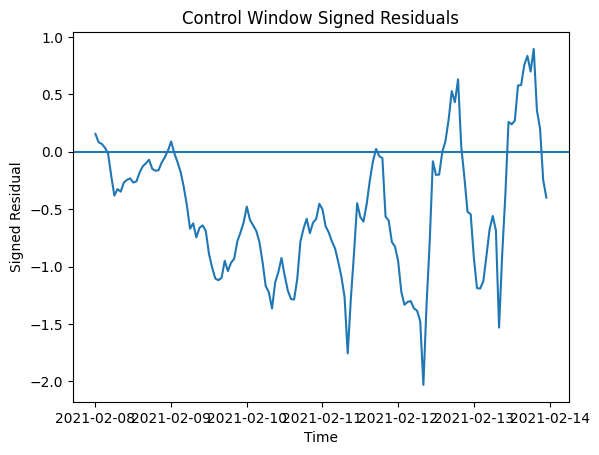

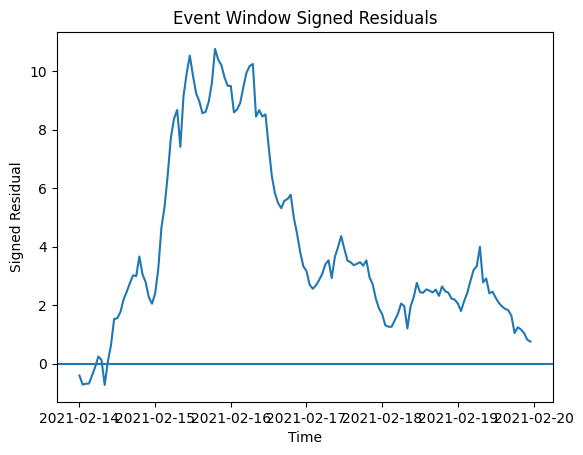

In [12]:
# TODO (students): plot the signed residual time series for the control and event windows.

# Plot the signed residuals for the control window.
# Positive residuals mean predicted load was higher than observed load.
# Negative residuals mean predicted load was lower than observed load.
plt.plot(control_r.index, control_r["resid"])

# Add a zero reference line to separate positive and negative residuals.
plt.axhline(0)

plt.title("Control Window Signed Residuals")
plt.xlabel("Time")
plt.ylabel("Signed Residual")
plt.show()

# Plot the signed residuals for the event window.
# This helps show the direction of the model error during the storm.
plt.plot(event_r.index, event_r["resid"])

# Add a zero reference line.
plt.axhline(0)

plt.title("Event Window Signed Residuals")
plt.xlabel("Time")
plt.ylabel("Signed Residual")
plt.show()





Part 5: Signed Residuals
On February 15 and 16, the residuals are large and positive, which means the model predicted more load than what was actually observed. The temperature was extremely low, so based on the normal behavior learned during training, the model expected higher electricity load because people would normally use more electricity for heating. However, during the load-shedding period, the observed load was much lower than predicted. The positive residual represents the gap between the load expected by the model and the load actually observed by ERCOT.

## Part 6: build the detector

The detector labels an hour as unusual when the size of its residual is above a threshold:

$$\text{flag}(t) = \mathbb{1}\left[\,\lvert r(t) \rvert > k\,\sigma_{\text{control}}\,\right]$$

Here $\sigma_{\text{control}}$ is the spread of the residuals during the ordinary control week. The number
$k$ controls how sensitive the detector is. A smaller $k$ flags more hours. A larger $k$ flags fewer hours.

A **false alarm** happens when the detector flags an hour in the control week even though that week is being
treated as normal. The **false-alarm rate** is the fraction of control hours that are flagged. For example,
if 6 of 100 control hours are flagged, the false-alarm rate is 6%.

Try several values of $k$. For each value, report the percentage of control hours and event hours that are
flagged. Choose a value that keeps the control percentage reasonably low while still identifying event hours.

The same control week is used here to calculate $\sigma_{\text{control}}$ and to count false alarms, so the
result applies only to this sample. A larger study would use separate ordinary weeks to choose and evaluate
the threshold.

Finally, consider duration. One unusual hour may be noise, while several unusual hours in a row provide
stronger evidence of an event. Briefly describe how consecutive flags could improve the detector.

In [13]:
# TODO (students): try several values of k, report the flagged percentages for both windows, and choose k.

# Set the selected k value and calculate the detection threshold.
k = 2.7
threshold = k * sigma_control

# Flag hours where the absolute residual is greater than the threshold.
control_flags = np.abs(control_r["resid"]) > threshold
event_flags = np.abs(event_r["resid"]) > threshold

# Calculate the percentage of flagged hours in each window.
# The control percentage represents the false-alarm rate.
control_flag_percentage = control_flags.mean() * 100
event_flag_percentage = event_flags.mean() * 100

# Display the percentage of flagged hours for both windows.
print("Control flag percentage",control_flag_percentage)
print("Event flag percentage",event_flag_percentage)




Control flag percentage 1.3888888888888888
Event flag percentage 84.02777777777779


Consecutive Flags:
One flagged hour could be caused by noise or a temporary prediction error. Requiring several consecutive flagged hours, such as three hours in a row, would provide stronger evidence that an unusual event is actually occurring. This could reduce false alarms, although it may slightly delay the detection of an event.

Limitation: The same control week was used to calculate sigma_control and evaluate the false-alarm rate. Therefore, the 1.39% false-alarm rate applies only to this control sample and may be different for other ordinary weeks. In a larger study, separate ordinary weeks could be used to select and evaluate the threshold.

## Part 7: write up

Answer the questions in the Markdown cells below. Replace each placeholder with your answer. Refer to the
numbers, plots, and tables you produced above. Do not write a separate README.

### 1. How accurate is the baseline?

Report sigma_train, sigma_control, and their ratio. What does the difference tell you?

**Answer:** _Write your answer here._

sigma_train   = 0.3151   (days the model was fitted to)
sigma_control = 0.5681   (unseen ordinary days)
ratio         = 1.80
sigma_train = 0.3151 and sigma_control = 0.5681, with a ratio of 1.80. This means that the residuals in the unseen control window are about 1.8 times more spread out than the residuals in the training window. The model therefore has larger prediction errors on unseen ordinary data than on the data it was fitted to.

This makes sense because the model was trained on the training window, so it generally fits those observations better than new, unseen observations.

### 2. Does the storm week look different?

Compare the control and event errors. State whether the residuals separate the two weeks and cite your
results.

**Answer:** _Write your answer here._

Control MSE relative to training per window: 6.038814084297986
Event MSE relative to training per window: 258.22716278180127
Control MSE relative per day: 2021-02-08    0.388315
2021-02-09    5.796957
2021-02-10    8.793052
2021-02-11    6.227692
2021-02-12    9.108829
2021-02-13    5.918039
Name: resid, dtype: float64
Event MSE relative per day: 2021-02-14     36.471324
2021-02-15    738.579696
2021-02-16    572.033130
2021-02-17    105.886310
2021-02-18     46.013306
2021-02-19     50.379210
Name: resid, dtype: float64

Yes, the storm week looks clearly different from the control week. The control MSE relative to training was 6.04, while the event MSE was much larger at 258.23. The daily values also show clear separation: the highest control value was 9.11, while the lowest event value was 36.47. The largest errors occurred on February 15 and 16, with relative MSE values of 738.58 and 572.03. These results show that the frozen model had much larger prediction errors during the storm week than during the ordinary control week.


### 3. What happened during load shedding?

On 15 and 16 February, were the residuals mostly positive or negative? Explain what that sign means in terms
of predicted and observed load.

**Answer:** _Write your answer here._

On February 15 and 16, the residuals were mostly positive. This means the model predicted a higher electricity load than what was actually observed. During the storm, the model expected high electricity use because of the very cold weather, but the actual load was lower because of load shedding.

### 4. How did your detector perform?

State the value of k you chose. Report the percentage of control hours and event hours that it flagged. The
control percentage is the false-alarm rate for this exercise.

**Answer:** _Write your answer here._

I chose k = 2.7. The detector flagged 1.39% of the control hours and 84.03% of the event hours. This means the false-alarm rate was 1.39%, while the detector identified most of the hours during the storm event.

### 5. What else could cause a large residual?

Give one normal situation that this model might flag and explain how you could distinguish it from a grid
event.

**Answer:** _Write your answer here._

A local power outage could cause a large residual because the actual electricity use may suddenly drop. We could check grid information to see if it was only a local outage or part of a larger grid event.

### 6. How could duration improve the detector?

Explain how you would use several flagged hours in a row instead of treating every hour separately.

**Answer:** _Write your answer here._

Instead of treating one flagged hour as an event, we could look for several flagged hours in a row. This would reduce false alarms because one unusual hour could just be noise, while several consecutive flagged hours give stronger evidence of a real event.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit
this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.